# Titanic 생존자 예측 ML

**목표:** titanic.csv 데이터로 생존 여부(Survived)를 예측하는 분류 모델 개발

**모델:** 로지스틱 회귀 / 결정 트리 / 랜덤 포레스트 비교 + K-Fold CV + GridSearchCV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 한글 폰트 설정
font_prop = fm.FontProperties(fname='/System/Library/Fonts/Supplemental/AppleGothic.ttf')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

import os
os.makedirs('../output', exist_ok=True)

print("라이브러리 로드 완료")

라이브러리 로드 완료


## Step 1. 데이터 살펴보기

In [2]:
df = pd.read_csv('../resources/titanic.csv')

print("=== 기본 정보 ===")
print(f"Shape: {df.shape}")
print(f"\n컬럼: {df.columns.tolist()}")
df.head()

=== 기본 정보 ===
Shape: (891, 12)

컬럼: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("=== 데이터 타입 ===")
print(df.dtypes)
print("\n=== 결측값 현황 ===")
print(df.isnull().sum())
print(f"\n결측값 비율:")
print((df.isnull().sum() / len(df) * 100).round(1))

=== 데이터 타입 ===
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

=== 결측값 현황 ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

결측값 비율:
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64


In [4]:
print("=== 수치형 통계 요약 ===")
display(df.describe())

print("\n=== 타겟 클래스 분포 ===")
survived_counts = df['Survived'].value_counts()
print(survived_counts)
print(f"\n생존율: {df['Survived'].mean():.1%}")

=== 수치형 통계 요약 ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== 타겟 클래스 분포 ===
Survived
0    549
1    342
Name: count, dtype: int64

생존율: 38.4%


## Step 2. 데이터 전처리

In [5]:
df_clean = df.copy()

# 결측값 처리 (pandas 3.x Copy-on-Write로 inplace 미사용)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# 불필요 컬럼 제거 (Cabin은 77% 결측으로 제거)
df_clean = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# 범주형 인코딩
df_clean['Sex'] = LabelEncoder().fit_transform(df_clean['Sex'])
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True, dtype=int)

print("전처리 완료")
print(f"Shape: {df_clean.shape}")
print(f"결측값: {df_clean.isnull().sum().sum()}")
df_clean.head()

전처리 완료
Shape: (891, 9)
결측값: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


In [6]:
# 피처 / 타겟 분리 및 학습/검증 분할
X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"학습 세트: {X_train.shape}, 검증 세트: {X_test.shape}")
print(f"피처 목록: {X.columns.tolist()}")

학습 세트: (712, 8), 검증 세트: (179, 8)
피처 목록: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


## Step 3. EDA (탐색적 데이터 분석)

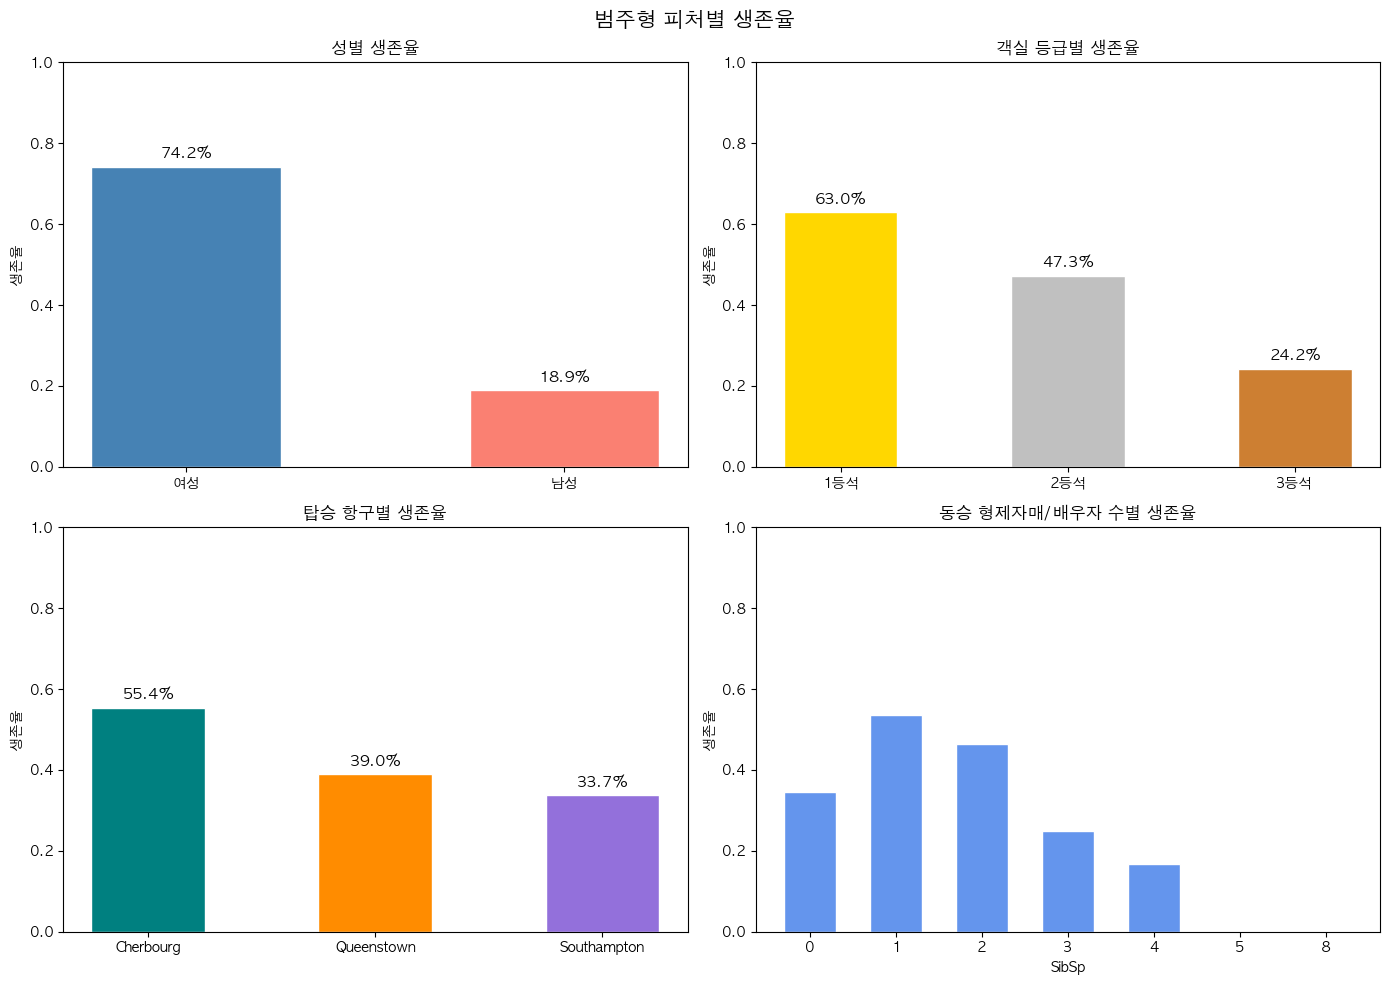

저장: output/01_categorical_survival.png


In [7]:
# 범주형 피처별 생존율 비교 (2x2 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('범주형 피처별 생존율', fontsize=15, fontweight='bold')

# 성별
sex_survival = df.groupby('Sex')['Survived'].mean().reset_index()
sex_survival['Sex_label'] = sex_survival['Sex'].map({'male': '남성', 'female': '여성'})
axes[0, 0].bar(sex_survival['Sex_label'], sex_survival['Survived'],
               color=['steelblue', 'salmon'], edgecolor='white', width=0.5)
axes[0, 0].set_title('성별 생존율')
axes[0, 0].set_ylabel('생존율')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(sex_survival['Survived']):
    axes[0, 0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)

# 객실 등급
pclass_survival = df.groupby('Pclass')['Survived'].mean()
axes[0, 1].bar([f'{c}등석' for c in pclass_survival.index], pclass_survival.values,
               color=['gold', 'silver', '#cd7f32'], edgecolor='white', width=0.5)
axes[0, 1].set_title('객실 등급별 생존율')
axes[0, 1].set_ylabel('생존율')
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(pclass_survival.values):
    axes[0, 1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)

# 탑승 항구
embarked_survival = df.groupby('Embarked')['Survived'].mean()
embarked_labels = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
axes[1, 0].bar([embarked_labels[e] for e in embarked_survival.index], embarked_survival.values,
               color=['teal', 'darkorange', 'mediumpurple'], edgecolor='white', width=0.5)
axes[1, 0].set_title('탑승 항구별 생존율')
axes[1, 0].set_ylabel('생존율')
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(embarked_survival.values):
    axes[1, 0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)

# SibSp (형제자매/배우자)
sibsp_survival = df.groupby('SibSp')['Survived'].mean()
axes[1, 1].bar(sibsp_survival.index.astype(str), sibsp_survival.values,
               color='cornflowerblue', edgecolor='white', width=0.6)
axes[1, 1].set_title('동승 형제자매/배우자 수별 생존율')
axes[1, 1].set_xlabel('SibSp')
axes[1, 1].set_ylabel('생존율')
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../output/01_categorical_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: output/01_categorical_survival.png")

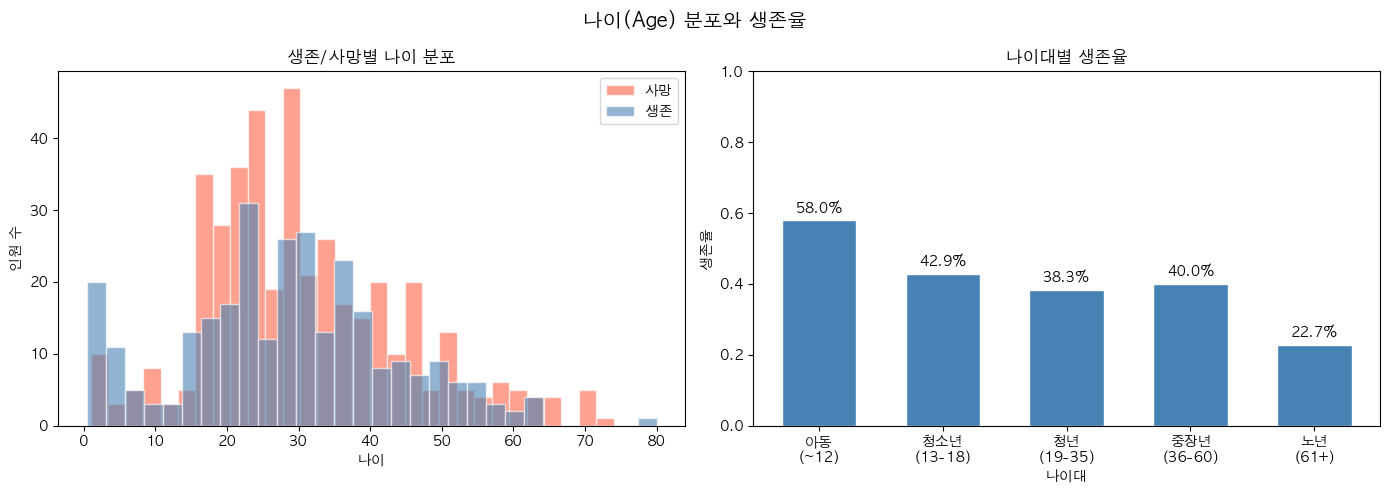

저장: output/02_age_survival.png


In [8]:
# 나이 분포 및 생존율
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('나이(Age) 분포와 생존율', fontsize=14, fontweight='bold')

# 생존/사망별 나이 분포
for survived, label, color in [(0, '사망', 'tomato'), (1, '생존', 'steelblue')]:
    axes[0].hist(df[df['Survived'] == survived]['Age'].dropna(),
                 bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('생존/사망별 나이 분포')
axes[0].set_xlabel('나이')
axes[0].set_ylabel('인원 수')
axes[0].legend()

# 나이대별 생존율
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['아동\n(~12)', '청소년\n(13-18)', '청년\n(19-35)', '중장년\n(36-60)', '노년\n(61+)'])
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean()
axes[1].bar(age_survival.index, age_survival.values, color='steelblue', edgecolor='white', width=0.6)
axes[1].set_title('나이대별 생존율')
axes[1].set_xlabel('나이대')
axes[1].set_ylabel('생존율')
axes[1].set_ylim(0, 1)
for i, v in enumerate(age_survival.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../output/02_age_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: output/02_age_survival.png")

# AgeGroup 임시 컬럼 제거
df.drop(columns=['AgeGroup'], inplace=True)

## Step 4. 모델 가설

**가설:** 여성, 1등석, 어린 나이일수록 생존 가능성이 높다.  
→ `Sex`, `Pclass`, `Age`가 가장 중요한 예측 피처일 것이다.

**검증 방법:** 3가지 모델 학습 후 피처 중요도(Feature Importance)로 확인

## Step 5. 모델 학습 및 평가

### 5-1. 기본 모델 비교 (결정 트리 / 랜덤 포레스트 / 로지스틱 회귀)

In [9]:
models = {
    '로지스틱 회귀': LogisticRegression(max_iter=1000, random_state=42),
    '결정 트리': DecisionTreeClassifier(max_depth=5, random_state=42),
    '랜덤 포레스트': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'pred': y_pred, 'accuracy': acc}
    print(f"\n{'='*40}")
    print(f"[{name}]  Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['사망', '생존']))


[로지스틱 회귀]  Accuracy: 0.8101
              precision    recall  f1-score   support

          사망       0.83      0.86      0.84       105
          생존       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


[결정 트리]  Accuracy: 0.7989
              precision    recall  f1-score   support

          사망       0.79      0.90      0.84       105
          생존       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179




[랜덤 포레스트]  Accuracy: 0.8101
              precision    recall  f1-score   support

          사망       0.83      0.86      0.84       105
          생존       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



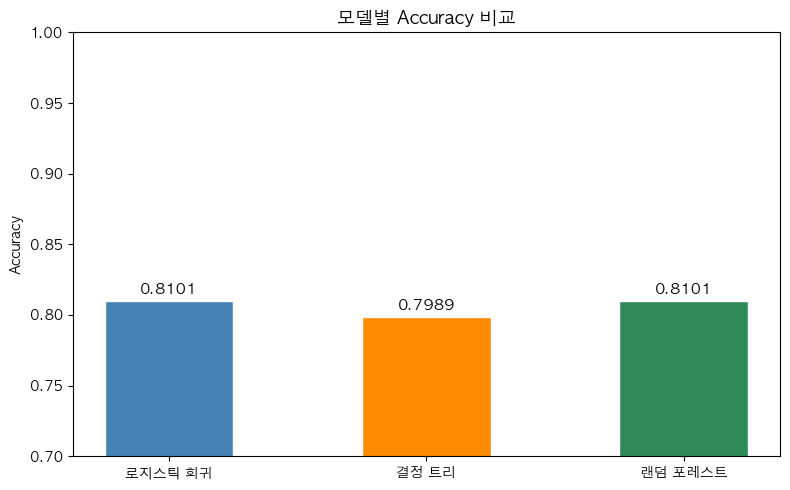

저장: output/03_model_comparison.png


In [10]:
# 모델 성능 비교 차트
model_names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in model_names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, accuracies, color=['steelblue', 'darkorange', 'seagreen'],
              edgecolor='white', width=0.5)
ax.set_title('모델별 Accuracy 비교', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.0)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: output/03_model_comparison.png")

### 5-2. K-Fold 교차검증 (cross_val_score)

In [11]:
print("=== K-Fold 교차검증 (5-Fold) ===\n")
cv_results = {}
for name, info in results.items():
    cv_scores = cross_val_score(info['model'], X, y, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"[{name}]")
    print(f"  Fold 점수: {cv_scores.round(4)}")
    print(f"  평균: {cv_scores.mean():.4f}  표준편차: {cv_scores.std():.4f}\n")

=== K-Fold 교차검증 (5-Fold) ===



[로지스틱 회귀]
  Fold 점수: [0.7877 0.7865 0.7865 0.7697 0.8258]
  평균: 0.7912  표준편차: 0.0185

[결정 트리]
  Fold 점수: [0.8101 0.8202 0.8146 0.764  0.8539]
  평균: 0.8126  표준편차: 0.0288



[랜덤 포레스트]
  Fold 점수: [0.7989 0.8034 0.8483 0.7753 0.8146]
  평균: 0.8081  표준편차: 0.0238



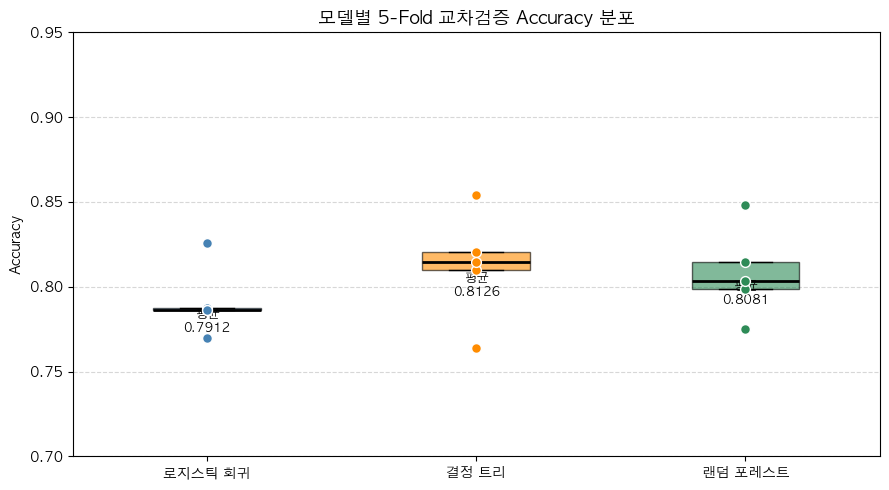

저장: output/05_cv_comparison.png


In [12]:
# 교차검증 결과 시각화 — 박스플롯 + 개별 Fold 점수
fig, ax = plt.subplots(figsize=(9, 5))

names = list(cv_results.keys())
scores = list(cv_results.values())
colors = ['steelblue', 'darkorange', 'seagreen']

# 박스플롯
bp = ax.boxplot(scores, patch_artist=True, widths=0.4,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# 개별 Fold 점수 산점도
for i, (score, color) in enumerate(zip(scores, colors), start=1):
    ax.scatter([i] * len(score), score, color=color, zorder=5, s=50, edgecolors='white')

# 평균 수치 표시
for i, score in enumerate(scores, start=1):
    ax.text(i, score.mean() - 0.018, f'평균\n{score.mean():.4f}',
            ha='center', fontsize=9, color='black')

ax.set_xticks(range(1, len(names) + 1))
ax.set_xticklabels(names)
ax.set_title('모델별 5-Fold 교차검증 Accuracy 분포', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.70, 0.95)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../output/05_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: output/05_cv_comparison.png")

### 5-3. 하이퍼파라미터 튜닝 (GridSearchCV) — 랜덤 포레스트

In [13]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f"최적 파라미터: {grid_search.best_params_}")
print(f"CV 최고 점수: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"테스트 Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=['사망', '생존']))

최적 파라미터: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
CV 최고 점수: 0.8314
테스트 Accuracy: 0.8156
              precision    recall  f1-score   support

          사망       0.81      0.90      0.85       105
          생존       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



### 5-4. 피처 중요도 (가설 검증)

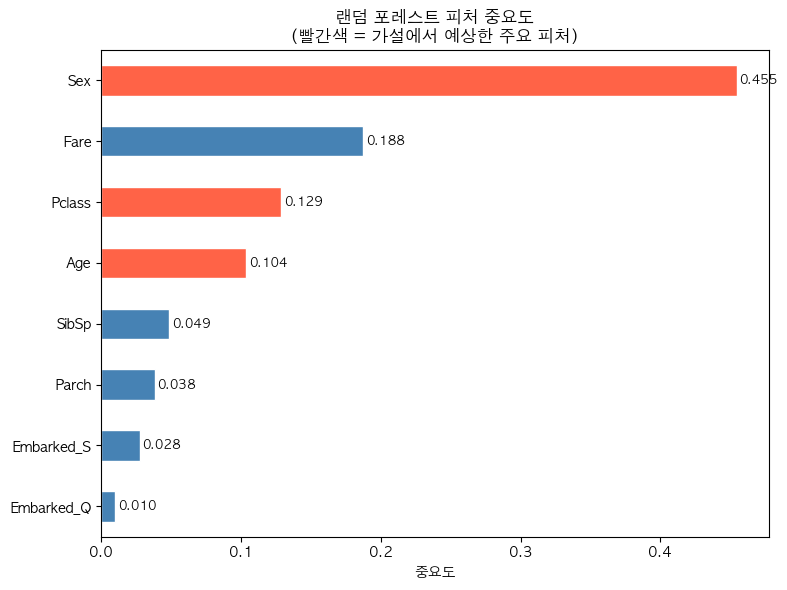

저장: output/04_feature_importance.png

=== 가설 검증 결과 ===
상위 3개 피처: ['Sex', 'Fare', 'Pclass']
가설(Sex, Pclass, Age) 검증: △ 부분 일치


In [14]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if feat in ['Sex', 'Pclass', 'Age'] else 'steelblue' for feat in importances.index]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('랜덤 포레스트 피처 중요도\n(빨간색 = 가설에서 예상한 주요 피처)', fontsize=12, fontweight='bold')
ax.set_xlabel('중요도')

# 수치 표시
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../output/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: output/04_feature_importance.png")

print("\n=== 가설 검증 결과 ===")
top3 = importances.sort_values(ascending=False).head(3).index.tolist()
print(f"상위 3개 피처: {top3}")
print(f"가설(Sex, Pclass, Age) 검증: {'✓ 일치' if set(top3) == {'Sex', 'Pclass', 'Age'} else '△ 부분 일치'}")